In [7]:
import boto3
from botocore.config import Config
from botocore import UNSIGNED
import pandas as pd

In [4]:
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
BUCKET_NAME = "a-book"

file_dict = s3.list_objects_v2(Bucket=BUCKET_NAME)['Contents']
file_dict

[{'Key': 'Dockerfile',
  'LastModified': datetime.datetime(2017, 10, 3, 22, 45, 40, tzinfo=tzutc()),
  'ETag': '"e83463d3f093a92055b154509d03ad9a"',
  'Size': 313,
  'StorageClass': 'STANDARD'},
 {'Key': 'Dockerfile.textClipping',
  'LastModified': datetime.datetime(2017, 10, 3, 22, 45, 40, tzinfo=tzutc()),
  'ETag': '"208f5aef2d98f7a86e1a56d05a60e9c3"',
  'Size': 203,
  'StorageClass': 'STANDARD'},
 {'Key': 'InteractivelyExploreDataWithSpark.html',
  'LastModified': datetime.datetime(2017, 10, 3, 22, 45, 51, tzinfo=tzutc()),
  'ETag': '"fa9eee8bb3c49c1bc2cb804458d5770f"',
  'Size': 354791,
  'StorageClass': 'STANDARD'},
 {'Key': 'Orienting.html',
  'LastModified': datetime.datetime(2017, 10, 3, 22, 46, 2, tzinfo=tzutc()),
  'ETag': '"84783ea04e1ff186acb90549700fd8c0"',
  'Size': 2435947,
  'StorageClass': 'STANDARD'},
 {'Key': 'README.md',
  'LastModified': datetime.datetime(2017, 10, 3, 22, 46, 6, tzinfo=tzutc()),
  'ETag': '"4b1f6545f533d00a8ae83b90a22bfea9"',
  'Size': 804,
  'Stor

In [6]:
for d in file_dict:
    file_name = d["Key"]
    if file_name.endswith(".csv"):
        print(file_name)

titanic.csv


In [9]:
BUCKET_NAME = "a-book"
FILE_NAME = "titanic.csv"

URL = f"https://{BUCKET_NAME}.s3.amazonaws.com/{FILE_NAME}"
df = pd.read_csv(URL)
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [18]:
URL

'https://a-book.s3.amazonaws.com/titanic.csv'

In [12]:
df = df[["sex", "survived", "age"]]
df

,sex,survived,age
0,female,1,29.00
1,male,1,0.92
2,female,0,2.00
3,male,0,30.00
4,female,0,25.00
...,...,...,...
1304,female,0,14.50
1305,female,0,NaN
1306,male,0,26.50
1307,male,0,27.00


In [13]:
df["sex"] = df["sex"] == "female"
df

/var/folders/3k/f_77v9pn1r94_xmvm2w3xgqr0000gn/T/ipykernel_3246/42080238.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sex"] = df["sex"] == "female"


,sex,survived,age
0,True,1,29.00
1,False,1,0.92
2,True,0,2.00
3,False,0,30.00
4,True,0,25.00
...,...,...,...
1304,True,0,14.50
1305,True,0,NaN
1306,False,0,26.50
1307,False,0,27.00


In [11]:
import matplotlib.pyplot as plt

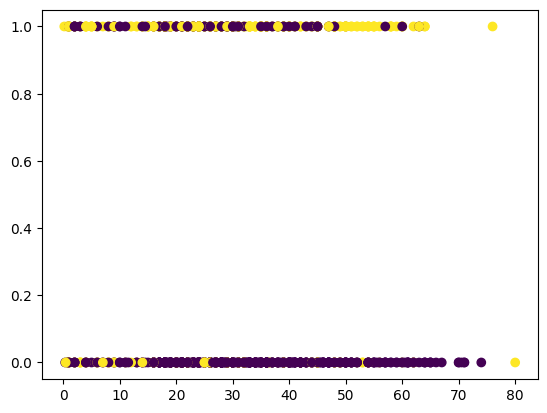

In [15]:
plt.scatter(df["age"], df["sex"], c=df["survived"])

In [16]:
plt.rcParams["figure.figsize"]

[6.4, 4.8]

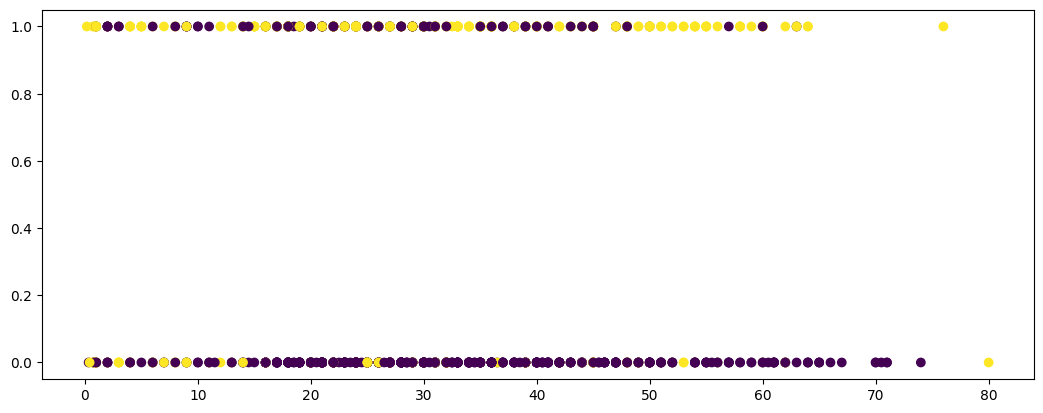

In [17]:
plt.rcParams["figure.figsize"] = [6.4 * 2, 4.8]
plt.scatter(df["age"], df["sex"], c=df["survived"])